In [36]:
import requests
import time
import threading

FUNCTION_URL = "http://115.146.92.205:31112/function/nodeinfo.openfaas-fn"
DURATION = 1 # Duration in seconds
# Number of concurrent requests to send
CONCURRENCY = 2

def send_request():
    try:
        res = requests.get(FUNCTION_URL)
        if res.status_code == 200:
            print("Request sent successfully")
        else:
            print(f"Failed to send request, status code: {res.status_code}")
    except requests.exceptions.RequestException as e:
        print(f"Error sending request: {e}")

start_time = time.time()
threads = []
while time.time() - start_time < DURATION:
    for _ in range(CONCURRENCY):
        thread = threading.Thread(target=send_request)
        threads.append(thread)
        thread.start()
    for thread in threads:
        thread.join()
    threads = []
    time.sleep(0.1)

Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully
Request sent successfully


In [3]:
import requests
import time
import re

LOKI_URL = "http://10.152.183.43:3100"  # change if using a remote server

# Loki query - adjust the label selector and filters as needed
query = '{job="openfaas/gateway"} |= "CustomNotifier"'

# Time range: last 1 hour
start = int((time.time() - 10 * 60 * 60) * 1e9)  # 10 hours ago
end = int(time.time() * 1e9)

params = {
    "query": query,
    "start": start,
    "end": end,
    "limit": 1000,
    "direction": "backward"
}

url = f"{LOKI_URL}/loki/api/v1/query_range"

response = requests.get(url, params=params)

def parse_log_line(line):
    # Regex to match key=value (both quoted and unquoted values)
    matches = re.findall(r'(\w+)=("[^"]+"|\S+)', line)
    return {key: value.strip('"') for key, value in matches}

if response.status_code == 200:
    print("Logs retrieved successfully")
    data = response.json()
    for stream in data["data"]["result"]:
        for log in stream["values"]:
            timestamp, line = log
            parsed = parse_log_line(line)
            print("Parsed log:", parsed)
            # Example: access duration or method
            print("Method:", parsed.get("Method"))
            print("Duration (s):", parsed.get("Duration", "0s").rstrip("s"))
else:
    print("Error:", response.status_code, response.text)


Logs retrieved successfully


### Cost minimisation with Un-Served Penalty i.e. Best-Effort Execution

In [5]:
# !pip install pulp
from pulp import (
    LpProblem, LpVariable, LpMinimize, lpSum,
    LpInteger, value, LpStatus
)

# --------------------------------------------
# 1. INPUT DEFINITIONS
# --------------------------------------------

# Request Types with resource requirements and demand
request_types = {
    'A': {'cpu': 10, 'mem': 100, 'demand': 3000},
    'B': {'cpu': 20, 'mem': 200, 'demand': 1000},
}

# Instance Types (function configurations)
instance_types = {
    'X': {'cpu': 10, 'mem': 100, 'cost': 5, 'capacity': 100},
    'Y': {'cpu': 20, 'mem': 200, 'cost': 8, 'capacity': 100},
    'Z': {'cpu': 40, 'mem': 400, 'cost': 14, 'capacity': 100},
}

# Cluster Resource Capacity (total available)
cluster_cpu = 200
cluster_mem = 20000

# Weights for overprovisioning cost
alpha = 1  # CPU mismatch penalty weight
beta = 1   # MEM mismatch penalty weight

# Penalty for unserved requests
unserved_penalty = {
    'A': 15,
    'B': 20,
}

# --------------------------------------------
# 2. PROBLEM DEFINITION
# --------------------------------------------

# Define the ILP minimization problem
prob = LpProblem("Function_Instance_Rebalancing_BestEffort", LpMinimize)

# --------------------------------------------
# 3. DECISION VARIABLES
# --------------------------------------------

# Number of instances of each type to provision
x = {i: LpVariable(f"x_{i}", 0, cat=LpInteger) for i in instance_types}

# Number of requests of type k served by instance type i
y = {
    (k, i): LpVariable(f"y_{k}_{i}", 0, cat=LpInteger)
    for k in request_types
    for i in instance_types
    if instance_types[i]['cpu'] >= request_types[k]['cpu'] and instance_types[i]['mem'] >= request_types[k]['mem']
}

# Number of requests actually served (best-effort)
served = {
    k: LpVariable(f"served_{k}", 0, request_types[k]['demand'], cat=LpInteger)
    for k in request_types
}

# --------------------------------------------
# 4. OBJECTIVE FUNCTION
# --------------------------------------------

# Minimize: Instance cost + overprovisioning waste + penalty for unserved requests
prob += (
    lpSum(x[i] * instance_types[i]['cost'] for i in instance_types)
    + lpSum(
        y[(k, i)] * (
            alpha * (instance_types[i]['cpu'] - request_types[k]['cpu'])**2 +
            beta * (instance_types[i]['mem'] - request_types[k]['mem'])**2
        )
        for (k, i) in y
    )
    + lpSum(
        (request_types[k]['demand'] - served[k]) * unserved_penalty[k]
        for k in request_types
    )
)

# --------------------------------------------
# 5. CONSTRAINTS
# --------------------------------------------

# Constraint: Served requests must match total assignment across all eligible instance types
for k in request_types:
    prob += (
        lpSum(y[(k, i)] for i in instance_types
              if (k, i) in y) == served[k]
    )

# Constraint: Do not exceed instance capacity
for i in instance_types:
    prob += (
        lpSum(
            y[(k, i)]
            for k in request_types
            if (k, i) in y
        ) <= x[i] * instance_types[i]['capacity']
    )

# Constraint: Stay within cluster CPU and Memory limits
prob += lpSum(x[i] * instance_types[i]['cpu'] for i in instance_types) <= cluster_cpu
prob += lpSum(x[i] * instance_types[i]['mem'] for i in instance_types) <= cluster_mem

# --------------------------------------------
# 6. SOLVE
# --------------------------------------------

prob.solve()

# --------------------------------------------
# 7. OUTPUT RESULTS
# --------------------------------------------

print(f"\n🔍 Solver Status: {LpStatus[prob.status]}")

if LpStatus[prob.status] == "Optimal":
    print("\n📦 Instance Allocation:")
    for i in instance_types:
        print(f"  {i}: {int(x[i].varValue)} instance(s)")

    print("\n📊 Request Assignments:")
    for (k, i), var in y.items():
        if var.varValue is not None and var.varValue > 0:
            print(f"  {int(var.varValue)} requests of type {k} → instance {i}")

    print("\n✅ Best-Effort Request Coverage:")
    for k in request_types:
        actual = int(served[k].varValue)
        total = request_types[k]['demand']
        print(f"  {k}: {actual}/{total} requests served ({100*actual/total:.1f}%)")

    print(f"\n💰 Total Cost: {value(prob.objective)}")
else:
    print("❌ No feasible solution found.")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/ubuntu/miniconda/miniconda/envs/memfigless/lib/python3.12/site-packages/pulp/solverdir/cbc/linux/64/cbc /home/ubuntu/memFigLessDIR/tmpdir/5c110a542db6453785e021b63f04677e-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /home/ubuntu/memFigLessDIR/tmpdir/5c110a542db6453785e021b63f04677e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 62 RHS
At line 70 BOUNDS
At line 81 ENDATA
Problem MODEL has 7 rows, 10 columns and 21 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -29900 - 0.00 seconds
Cgl0004I processed model has 6 rows, 10 columns (10 integer (0 of which binary)) and 18 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0012I Integer solution of -29900 found by DiveCoefficient after 0 iterations and 0 nodes (0.00 seconds)
Cbc0001I Search

### Cost Minimisation with Un-Served Penalty and Function Utility

In [15]:
# !pip install pulp
from pulp import (
    LpProblem, LpVariable, LpMinimize, lpSum,
    LpInteger, value, LpStatus
)

# Request Types with resource requirements and demand
request_types = {
    'A': {'cpu': 10, 'mem': 100, 'demand': 3000},
    'B': {'cpu': 20, 'mem': 200, 'demand': 1000},
}

# Instance Types (function configurations)
instance_types = {
    'X': {'cpu': 10, 'mem': 100, 'cost': 5, 'capacity': 100},
    'Y': {'cpu': 20, 'mem': 200, 'cost': 8, 'capacity': 100},
    'Z': {'cpu': 40, 'mem': 400, 'cost': 14, 'capacity': 100},
}

# Cluster Resource Capacity (total available)
cluster_cpu = 200
cluster_mem = 20000

# Penalties
alpha = 1  # CPU overprovisioning penalty
beta = 1   # MEM overprovisioning penalty
unserved_penalty = {'A': 20, 'B': 20}

# Utilities
utility = {'A': 1, 'B': 1}
lambda_util = 1.0  # Weight of utility term in objective

# Define the problem
prob = LpProblem("Function_Instance_Rebalancing_With_Utility", LpMinimize)

# Decision Variables
x = {i: LpVariable(f"x_{i}", 0, cat=LpInteger) for i in instance_types}
y = {
    (k, i): LpVariable(f"y_{k}_{i}", 0, cat=LpInteger)
    for k in request_types for i in instance_types
    if instance_types[i]['cpu'] >= request_types[k]['cpu'] and instance_types[i]['mem'] >= request_types[k]['mem']
}
served = {
    k: LpVariable(f"served_{k}", 0, request_types[k]['demand'], cat=LpInteger)
    for k in request_types
}

# Objective: minimize total cost - reward utility
prob += (
    lpSum(x[i] * instance_types[i]['cost'] for i in instance_types) +  # instance cost
    lpSum(
        y[(k, i)] * (
            alpha * (instance_types[i]['cpu'] - request_types[k]['cpu'])**2 +
            beta * (instance_types[i]['mem'] - request_types[k]['mem'])**2
        )
        for (k, i) in y
    ) +  # overprovisioning penalty
    lpSum(
        (request_types[k]['demand'] - served[k]) * unserved_penalty[k]
        for k in request_types
    ) -  # penalty for unserved
    lambda_util * lpSum(served[k] * utility[k] for k in request_types)  # utility reward
)

# Constraints
for k in request_types:
    prob += (
        lpSum(y[(k, i)] for i in instance_types if (k, i) in y) == served[k]
    )

for i in instance_types:
    prob += (
        lpSum(y[(k, i)] for k in request_types if (k, i) in y) <= x[i] * instance_types[i]['capacity']
    )

prob += lpSum(x[i] * instance_types[i]['cpu'] for i in instance_types) <= cluster_cpu
prob += lpSum(x[i] * instance_types[i]['mem'] for i in instance_types) <= cluster_mem

# Solve
prob.solve()

# Results
print(f"\n🔍 Solver Status: {LpStatus[prob.status]}")

print("\n📦 Instance Allocation:")
for i in instance_types:
    print(f"  {i}: {int(x[i].varValue)} instance(s)")

print("\n📊 Request Assignments:")
for (k, i), var in y.items():
    if var.varValue and var.varValue > 0:
        print(f"  {int(var.varValue)} requests of type {k} → instance {i}")

print("\n✅ Best-Effort Request Coverage:")
for k in request_types:
    actual = int(served[k].varValue)
    total = request_types[k]['demand']
    print(f"  {k}: {actual}/{total} served ({100 * actual / total:.1f}%)")

print(f"\n💰 Total Cost (with utility penalty): {value(prob.objective)}")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/ubuntu/miniconda/miniconda/envs/memfigless/lib/python3.12/site-packages/pulp/solverdir/cbc/linux/64/cbc /home/ubuntu/memFigLessDIR/tmpdir/b802551c2be2418e9dfe3da79728759e-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /home/ubuntu/memFigLessDIR/tmpdir/b802551c2be2418e9dfe3da79728759e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 62 RHS
At line 70 BOUNDS
At line 81 ENDATA
Problem MODEL has 7 rows, 10 columns and 21 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -41900 - 0.00 seconds
Cgl0004I processed model has 6 rows, 10 columns (10 integer (0 of which binary)) and 18 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0012I Integer solution of -41900 found by DiveCoefficient after 0 iterations and 0 nodes (0.00 seconds)
Cbc0001I Search

### Cost Minimisation with Un-Served Capacity, Function Utility and Normalisation

In [22]:
# !pip install pulp
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpInteger, value, LpStatus

# Request Types: resource needs and demand
request_types = {
    'A': {'cpu': 10, 'mem': 100, 'demand': 3000},
    'B': {'cpu': 20, 'mem': 200, 'demand': 1000},
}

# Instance Types: resource config, cost, and max request capacity
instance_types = {
    'X': {'cpu': 10, 'mem': 100, 'cost': 5, 'capacity': 100},
    'Y': {'cpu': 20, 'mem': 200, 'cost': 8, 'capacity': 100},
    'Z': {'cpu': 40, 'mem': 400, 'cost': 14, 'capacity': 100},
}

# Cluster capacity constraints
cluster_cpu = 200
cluster_mem = 20000

# Penalty parameters
alpha, beta = 1, 1  # Overprovisioning weights
unserved_penalty = {'A': 15, 'B': 20}

# Utility for serving each request
utility = {'A': 1, 'B': 3}
lambda_util = 1.5  # Weight for utility term

# Precompute normalizers
max_cost = max(i['cost'] for i in instance_types.values()) * (cluster_cpu // min(i['cpu'] for i in instance_types.values()))
max_penalty = sum(request_types[k]['demand'] * unserved_penalty[k] for k in request_types)
max_utility = sum(request_types[k]['demand'] * utility[k] for k in request_types)

max_waste = 0
for k in request_types:
    for i in instance_types:
        if instance_types[i]['cpu'] >= request_types[k]['cpu'] and instance_types[i]['mem'] >= request_types[k]['mem']:
            waste = (alpha * (instance_types[i]['cpu'] - request_types[k]['cpu'])**2 +
                     beta * (instance_types[i]['mem'] - request_types[k]['mem'])**2)
            max_waste += request_types[k]['demand'] * waste

# Define the problem
prob = LpProblem("Function_Instance_Rebalancing_with_Utility", LpMinimize)

# Decision Variables
x = {i: LpVariable(f"x_{i}", 0, cat=LpInteger) for i in instance_types}
y = {(k, i): LpVariable(f"y_{k}_{i}", 0, cat=LpInteger)
     for k in request_types for i in instance_types
     if instance_types[i]['cpu'] >= request_types[k]['cpu'] and instance_types[i]['mem'] >= request_types[k]['mem']}
served = {k: LpVariable(f"served_{k}", 0, request_types[k]['demand'], cat=LpInteger) for k in request_types}

# Normalized Objective Function
prob += (
    (lpSum(x[i] * instance_types[i]['cost'] for i in instance_types) / max_cost) +
    (lpSum(
        y[(k, i)] * (
            alpha * (instance_types[i]['cpu'] - request_types[k]['cpu'])**2 +
            beta * (instance_types[i]['mem'] - request_types[k]['mem'])**2
        )
        for (k, i) in y
    ) / max_waste) +
    (lpSum((request_types[k]['demand'] - served[k]) * unserved_penalty[k] for k in request_types) / max_penalty) -
    (lambda_util * lpSum(served[k] * utility[k] for k in request_types) / max_utility)
)

# Constraints
for k in request_types:
    prob += lpSum(y[(k, i)] for i in instance_types if (k, i) in y) == served[k]

for i in instance_types:
    prob += lpSum(y[(k, i)] for k in request_types if (k, i) in y) <= x[i] * instance_types[i]['capacity']

prob += lpSum(x[i] * instance_types[i]['cpu'] for i in instance_types) <= cluster_cpu
prob += lpSum(x[i] * instance_types[i]['mem'] for i in instance_types) <= cluster_mem

# Solve
prob.solve()

# Output
print(f"🔍 Solver Status: {LpStatus[prob.status]}\n")

print("📦 Instance Allocation:")
for i in instance_types:
    print(f"  {i}: {int(x[i].varValue)} instance(s)")

print("\n📊 Request Assignments:")
for k in request_types:
    for i in instance_types:
        if (k, i) in y and y[(k, i)].varValue > 0:
            print(f"  {int(y[(k, i)].varValue)} requests of type {k} → instance {i}")

print("\n✅ Best-Effort Request Coverage:")
for k in request_types:
    served_k = served[k].varValue
    print(f"  {k}: {int(served_k)}/{request_types[k]['demand']} requests served ({served_k / request_types[k]['demand'] * 100:.1f}%)")

print(f"\n💰 Total Cost: {value(prob.objective):.2f}")


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/ubuntu/miniconda/miniconda/envs/memfigless/lib/python3.12/site-packages/pulp/solverdir/cbc/linux/64/cbc /home/ubuntu/memFigLessDIR/tmpdir/2265f187f82e4f8a892ac1750adf7143-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /home/ubuntu/memFigLessDIR/tmpdir/2265f187f82e4f8a892ac1750adf7143-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 62 RHS
At line 70 BOUNDS
At line 81 ENDATA
Problem MODEL has 7 rows, 10 columns and 21 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -0.771978 - 0.00 seconds
Cgl0004I processed model has 6 rows, 10 columns (10 integer (0 of which binary)) and 18 elements
Cbc0012I Integer solution of -0.77197802 found by DiveCoefficient after 0 iterations and 0 nodes (0.00 seconds)
Cbc0001I Search completed - best objective -0.771978021

### Sensitivity Analysis for the given Input and Settings

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/ubuntu/miniconda/miniconda/envs/memfigless/lib/python3.12/site-packages/pulp/solverdir/cbc/linux/64/cbc /home/ubuntu/memFigLessDIR/tmpdir/db8cb00c0eec4700a1f52ac6b51e5344-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /home/ubuntu/memFigLessDIR/tmpdir/db8cb00c0eec4700a1f52ac6b51e5344-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 62 RHS
At line 70 BOUNDS
At line 81 ENDATA
Problem MODEL has 7 rows, 10 columns and 21 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is -1.03049 - 0.00 seconds
Cgl0004I processed model has 6 rows, 10 columns (10 integer (0 of which binary)) and 18 elements
Cbc0012I Integer solution of -0.98708791 found by DiveCoefficient after 0 iterations and 0 nodes (0.00 seconds)
Cbc0031I 1 added rows had average density of 4
Cbc0013I 

<Figure size 1400x600 with 0 Axes>

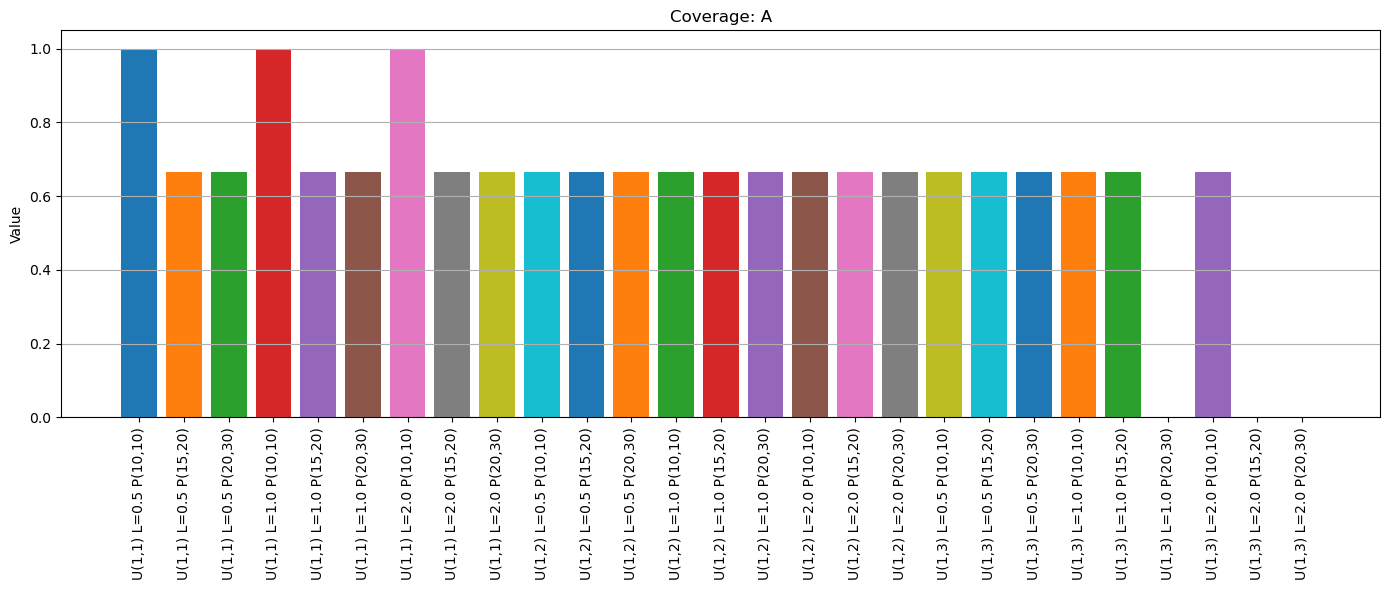

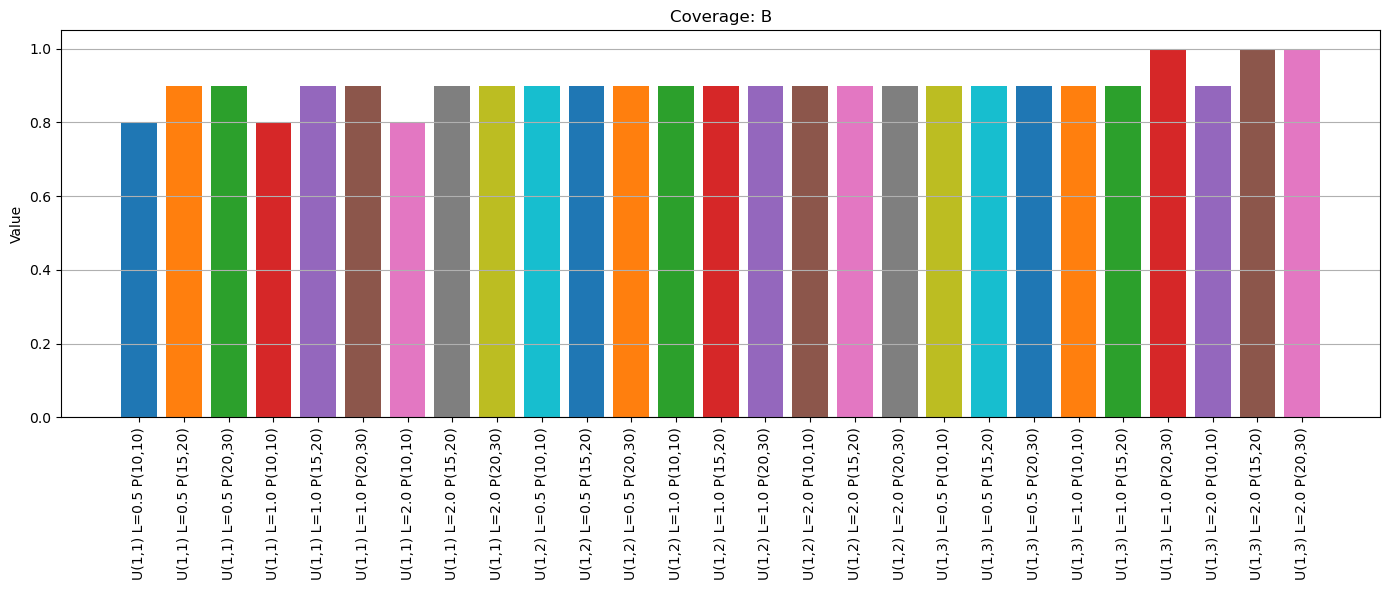

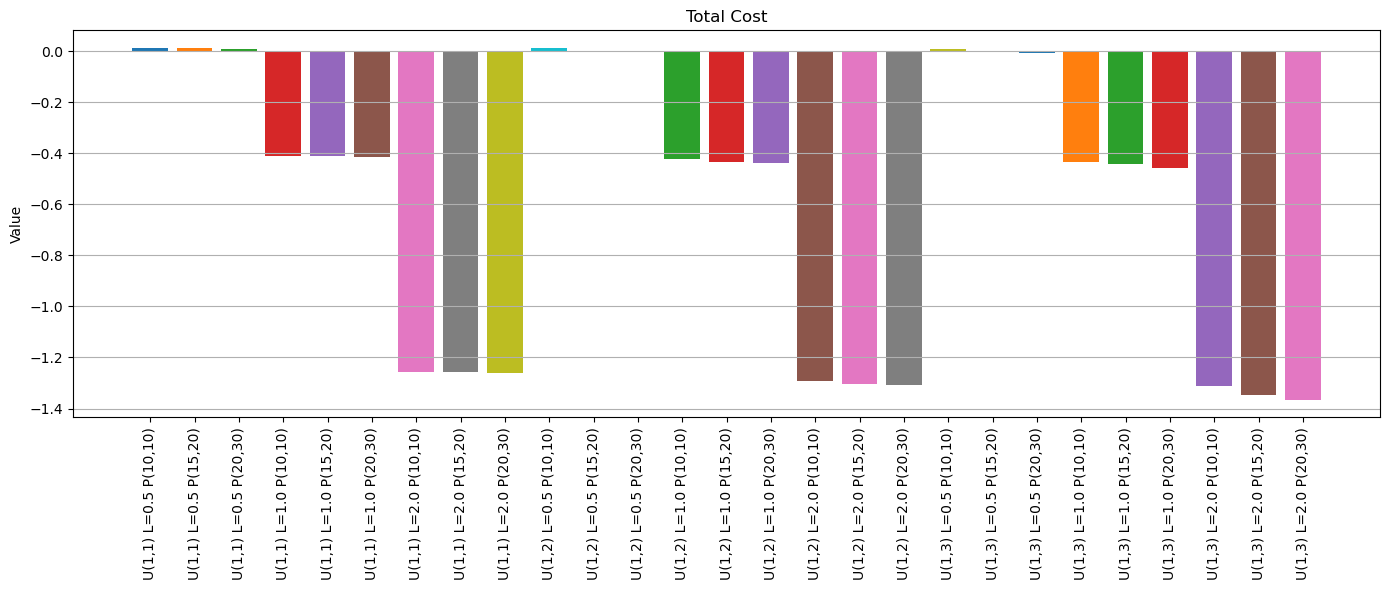

In [25]:
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpInteger, value, LpStatus

# Define fixed workload and instance profiles
request_types = {
    'A': {'cpu': 10, 'mem': 100, 'demand': 300},
    'B': {'cpu': 20, 'mem': 200, 'demand': 1000},
}

instance_types = {
    'X': {'cpu': 10, 'mem': 100, 'cost': 5, 'capacity': 100},
    'Y': {'cpu': 20, 'mem': 200, 'cost': 8, 'capacity': 100},
    'Z': {'cpu': 40, 'mem': 400, 'cost': 14, 'capacity': 100},
}

cluster_cpu = 200
cluster_mem = 20000
alpha, beta = 1, 1  # Overprovisioning weights

# Sweep over combinations of utility, lambda, and penalty
settings = []
results = []

utility_settings = [(1, 1), (1, 2), (1, 3)]
lambda_values = [0.5, 1.0, 2.0]
penalty_sets = [(10, 10), (15, 20), (20, 30)]

for ua, ub in utility_settings:
    for lmbda in lambda_values:
        for pa, pb in penalty_sets:
            utility = {'A': ua, 'B': ub}
            unserved_penalty = {'A': pa, 'B': pb}
            lambda_util = lmbda

            # Precompute normalizers
            max_cost = max(i['cost'] for i in instance_types.values()) * (cluster_cpu // min(i['cpu'] for i in instance_types.values()))
            max_penalty = sum(request_types[k]['demand'] * unserved_penalty[k] for k in request_types)
            max_utility = sum(request_types[k]['demand'] * utility[k] for k in request_types)

            max_waste = 0
            for k in request_types:
                for i in instance_types:
                    if instance_types[i]['cpu'] >= request_types[k]['cpu'] and instance_types[i]['mem'] >= request_types[k]['mem']:
                        waste = (alpha * (instance_types[i]['cpu'] - request_types[k]['cpu'])**2 +
                                 beta * (instance_types[i]['mem'] - request_types[k]['mem'])**2)
                        max_waste += request_types[k]['demand'] * waste

            # ILP setup
            prob = LpProblem("Sweep_Settings", LpMinimize)
            x = {i: LpVariable(f"x_{i}", 0, cat=LpInteger) for i in instance_types}
            y = {(k, i): LpVariable(f"y_{k}_{i}", 0, cat=LpInteger)
                 for k in request_types for i in instance_types
                 if instance_types[i]['cpu'] >= request_types[k]['cpu'] and instance_types[i]['mem'] >= request_types[k]['mem']}
            served = {k: LpVariable(f"served_{k}", 0, request_types[k]['demand'], cat=LpInteger) for k in request_types}

            # Objective
            prob += (
                (lpSum(x[i] * instance_types[i]['cost'] for i in instance_types) / max_cost) +
                (lpSum(
                    y[(k, i)] * (
                        alpha * (instance_types[i]['cpu'] - request_types[k]['cpu'])**2 +
                        beta * (instance_types[i]['mem'] - request_types[k]['mem'])**2
                    )
                    for (k, i) in y
                ) / max_waste) +
                (lpSum((request_types[k]['demand'] - served[k]) * unserved_penalty[k] for k in request_types) / max_penalty) -
                (lambda_util * lpSum(served[k] * utility[k] for k in request_types) / max_utility)
            )

            # Constraints
            for k in request_types:
                prob += lpSum(y[(k, i)] for i in instance_types if (k, i) in y) == served[k]

            for i in instance_types:
                prob += lpSum(y[(k, i)] for k in request_types if (k, i) in y) <= x[i] * instance_types[i]['capacity']

            prob += lpSum(x[i] * instance_types[i]['cpu'] for i in instance_types) <= cluster_cpu
            prob += lpSum(x[i] * instance_types[i]['mem'] for i in instance_types) <= cluster_mem

            prob.solve()

            # Store results
            result = {
                "setting": f"U({ua},{ub}) L={lmbda} P({pa},{pb})",
                "cost": value(prob.objective),
                "a_coverage": served['A'].varValue / request_types['A']['demand'],
                "b_coverage": served['B'].varValue / request_types['B']['demand'],
            }
            settings.append(result["setting"])
            results.append(result)

# Plot results
plt.figure(figsize=(14, 6))

for metric, title in zip(['a_coverage', 'b_coverage', 'cost'],
                         ['Coverage: A', 'Coverage: B', 'Total Cost']):
    plt.figure(figsize=(14, 6))
    for result in results:
        plt.bar(result['setting'], result[metric], label=result['setting'])
    plt.title(title)
    plt.ylabel('Value')
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.tight_layout()

plt.show()



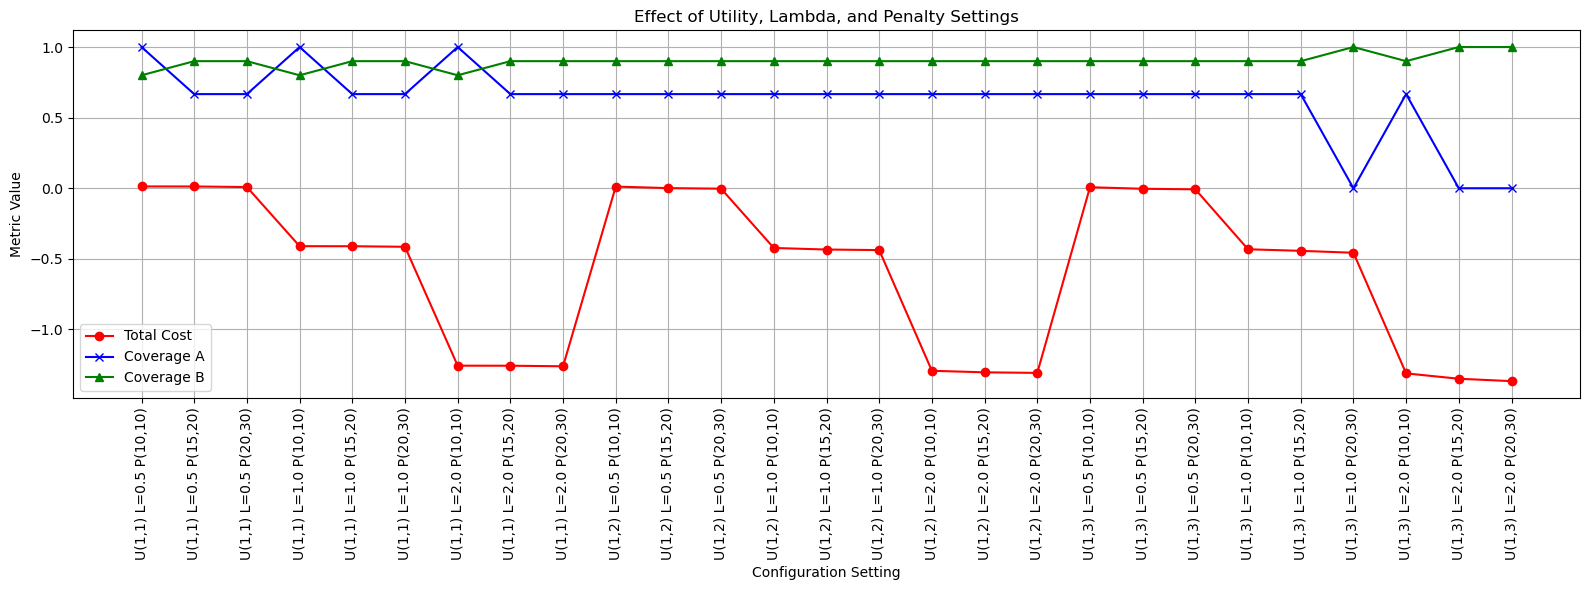

In [26]:
import matplotlib.pyplot as plt

# Assume you already have the `results` list from your ILP runs
# Example result structure:
# results = [
#     {"setting": "U(1,1) L=1.0 P(10,10)", "cost": 25000, "a_coverage": 0.75, "b_coverage": 0.65},
#     ...
# ]

# Generate index for x-axis
x_vals = list(range(len(results)))
labels = [res['setting'] for res in results]

# Extract metrics
costs = [res['cost'] for res in results]
a_covs = [res['a_coverage'] for res in results]
b_covs = [res['b_coverage'] for res in results]

plt.figure(figsize=(16, 6))

# Plot cost and coverages
plt.plot(x_vals, costs, label='Total Cost', color='red', marker='o')
plt.plot(x_vals, a_covs, label='Coverage A', color='blue', marker='x')
plt.plot(x_vals, b_covs, label='Coverage B', color='green', marker='^')

plt.xticks(x_vals, labels, rotation=90)
plt.xlabel("Configuration Setting")
plt.ylabel("Metric Value")
plt.title("Effect of Utility, Lambda, and Penalty Settings")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


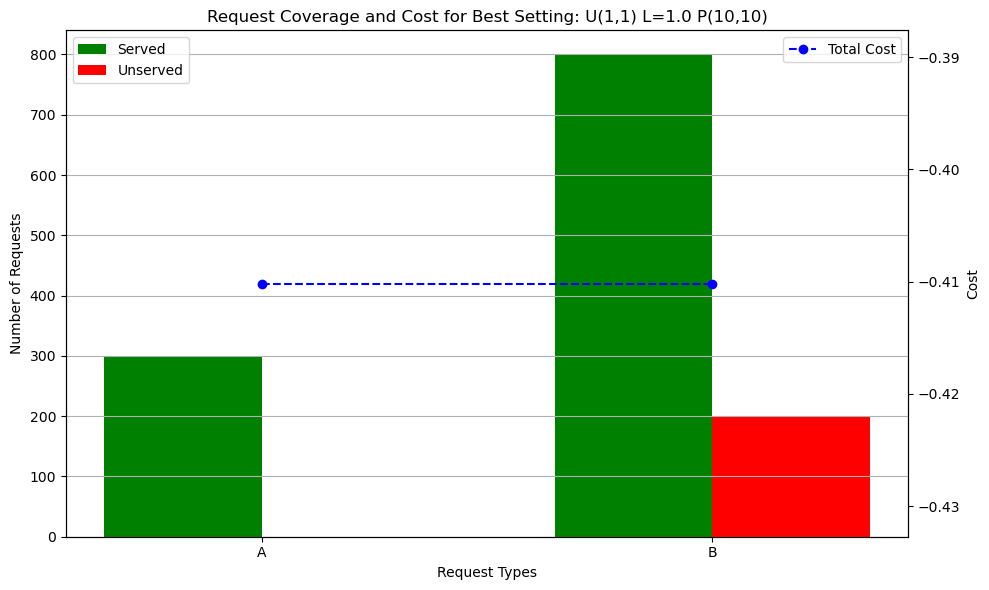

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Scoring function to pick best setting (adjust weights as needed)
def score_setting(result, weight_cost=0.5, weight_coverage=0.5):
    coverage_score = (result['a_coverage'] + result['b_coverage']) / 2
    cost_score = 1 / (1 + result['cost'])
    return weight_cost * cost_score + weight_coverage * coverage_score

# Pick best result
scored_results = [(score_setting(r), r) for r in results]
scored_results.sort(reverse=True, key=lambda x: x[0])
best_result = scored_results[0][1]

# Prepare data for plotting
request_labels = list(request_types.keys())
served = [best_result['a_coverage'] * request_types['A']['demand'],
          best_result['b_coverage'] * request_types['B']['demand']]
unserved = [request_types['A']['demand'] - served[0],
            request_types['B']['demand'] - served[1]]

x = np.arange(len(request_labels))  # label locations
width = 0.35  # bar width

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for served and unserved requests
bar1 = ax1.bar(x - width/2, served, width, label='Served', color='green')
bar2 = ax1.bar(x + width/2, unserved, width, label='Unserved', color='red')

ax1.set_xlabel('Request Types')
ax1.set_ylabel('Number of Requests')
ax1.set_title(f"Request Coverage and Cost for Best Setting: {best_result['setting']}")
ax1.set_xticks(x)
ax1.set_xticklabels(request_labels)
ax1.legend(loc='upper left')
ax1.grid(True, axis='y')

# Secondary axis for cost
ax2 = ax1.twinx()
ax2.plot(x, [best_result['cost']] * len(x), color='blue', marker='o', linestyle='--', label='Total Cost')
ax2.set_ylabel('Cost')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## ILP Solver as API service

In [ ]:
# ilp_solver_fastapi.py
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpInteger, value

app = FastAPI()

class RequestType(BaseModel):
    cpu: int
    mem: int
    demand: int

class InstanceType(BaseModel):
    cpu: int
    mem: int
    cost: float
    capacity: int

class ILPInput(BaseModel):
    cluster_cpu: int
    cluster_mem: int
    request_types: Dict[str, RequestType]
    instance_types: Dict[str, InstanceType]
    alpha: float = 1.0  # Overprovisioning CPU penalty
    beta: float = 1.0   # Overprovisioning MEM penalty
    lam: float = 1.0    # Utility weight
    utility: Dict[str, Dict[str, float]] = {}  # Optional utility matrix

@app.post("/solve")
def solve_ilp(input: ILPInput):
    rt = input.request_types
    it = input.instance_types
    cpu_cap = input.cluster_cpu
    mem_cap = input.cluster_mem
    alpha, beta, lam = input.alpha, input.beta, input.lam
    utility = input.utility

    prob = LpProblem("Function_Instance_Rebalancing", LpMinimize)

    x = {i: LpVariable(f"x_{i}", 0, cat=LpInteger) for i in it}
    y = {(k, i): LpVariable(f"y_{k}_{i}", 0, cat=LpInteger) for k in rt for i in it}

    prob += lpSum(
        x[i] * it[i].cost for i in it
    ) + lpSum(
        y[(k, i)] * (
            alpha * (it[i].cpu - rt[k].cpu) ** 2 +
            beta * (it[i].mem - rt[k].mem) ** 2 -
            lam * utility.get(i, {}).get(k, 1.0)
        )
        for k in rt for i in it
        if it[i].cpu >= rt[k].cpu and it[i].mem >= rt[k].mem
    )

    for k in rt:
        prob += lpSum(
            y[(k, i)]
            for i in it
            if it[i].cpu >= rt[k].cpu and it[i].mem >= rt[k].mem
        ) >= 0  # Best-effort relaxation

    for i in it:
        prob += lpSum(
            y[(k, i)]
            for k in rt
            if it[i].cpu >= rt[k].cpu and it[i].mem >= rt[k].mem
        ) <= x[i] * it[i].capacity

    prob += lpSum(x[i] * it[i].cpu for i in it) <= cpu_cap
    prob += lpSum(x[i] * it[i].mem for i in it) <= mem_cap

    prob.solve()

    x_result = {i: int(x[i].varValue or 0) for i in it}
    y_result = {
        k: {i: int(y[(k, i)].varValue or 0) for i in it if y[(k, i)].varValue and y[(k, i)].varValue > 0}
        for k in rt
    }
    coverage = {
        k: sum(y_result.get(k, {}).values()) / rt[k].demand if rt[k].demand > 0 else 1.0
        for k in rt
    }

    return {
        "instance_allocation": x_result,
        "request_assignments": y_result,
        "coverage_ratio": coverage,
        "total_cost": value(prob.objective),
        "status": prob.status
    }
